# Gün 8-9 — K-Means Segmentasyon

## Adım 1: PostgreSQL'den RFM verisini çekme ve normalizasyon

`segments` tablosunda her müşterinin **birden fazla** kaydı olabilir (her `/rfm/recalculate` çalıştırmasında yeni bir `calculated_at` ile geçmiş birikir). Kümeleme için her müşterinin sadece **en güncel** kaydını kullanıyoruz — `DISTINCT ON (customer_id)` ile bunu sağlıyoruz (Gün 3-4'te `/segments/summary` endpoint'inde de aynı deseni kullandık).

In [1]:
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv("../.env")

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

query = """
    SELECT DISTINCT ON (customer_id) customer_id, recency, frequency, monetary
    FROM segments
    ORDER BY customer_id, calculated_at DESC
"""

rfm = pd.read_sql(query, engine).set_index("customer_id")
print(rfm.shape)
rfm.head()

(5878, 3)


,recency,frequency,monetary
customer_id,,,
12346,325,12,77556.46
12347,2,8,5633.32
12348,75,5,2019.40
12349,18,4,4428.69
12350,310,1,334.40


In [2]:
rfm.describe()

,recency,frequency,monetary
count,5878.000000,5878.000000,5878.000000
mean,200.866791,6.289384,3018.616734
std,209.353961,13.009406,14737.731038
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,348.762500
50%,95.000000,3.000000,898.915000
75%,379.000000,7.000000,2307.090000
max,738.000000,398.000000,608821.650000


### Neden StandardScaler?

K-Means, müşteriler arası **Öklid mesafesine** dayanır. `monetary` binlerce TL/£ aralığında, `recency` ise 0-738 gün, `frequency` 1-398 fatura aralığında — ölçekler çok farklı. Ölçeklemeden kümeleme yaparsan, `monetary` sayısal olarak en büyük değerlere sahip olduğu için mesafe hesabına haksız yere domine eder; model aslında sadece harcamaya göre kümeleme yapar, recency/frequency'nin etkisi görünmez hale gelir.

`StandardScaler`, her sütunu ortalaması 0, standart sapması 1 olacak şekilde dönüştürür (`z = (x - mean) / std`) — böylece üç değişken kümeleme sürecinde eşit ağırlıkta söz hakkına sahip olur.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)
rfm_scaled_df.describe()

,recency,frequency,monetary
count,5.878000e+03,5.878000e+03,5.878000e+03
mean,1.692344e-17,-1.329699e-17,-2.417634e-18
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-9.595418e-01,-4.066161e-01,-2.046396e-01
25%,-8.401167e-01,-4.066161e-01,-1.811732e-01
50%,-5.057263e-01,-2.528681e-01,-1.438405e-01
75%,8.509434e-01,5.462788e-02,-4.828337e-02
max,2.565888e+00,3.011236e+01,4.110908e+01


## Adım 2: Elbow Curve + Silhouette Skoru ile Optimal K

**Elbow (dirsek) yöntemi**: K arttıkça küme içi karelerin toplamı (inertia / WCSS) hep azalır — soru, "ne zaman azalma yavaşlıyor" (dirsek noktası).

**Silhouette skoru**: Her noktanın kendi kümesine ne kadar yakın, diğer kümelere ne kadar uzak olduğunu ölçer (-1 ile 1 arası, yüksek = iyi ayrışmış kümeler). Elbow'un öznel olduğu yerde, silhouette sayısal bir karşılaştırma sağlar.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

results = pd.DataFrame({"k": list(k_range), "inertia": inertias, "silhouette": silhouette_scores})
results

,k,inertia,silhouette
0,2,12114.984358,0.923563
1,3,7124.426631,0.580285
2,4,5166.523749,0.591363
3,5,3910.191130,0.600438
4,6,3337.346101,0.590860
5,7,2754.741551,0.549168
6,8,2332.675284,0.510736
7,9,1910.515495,0.541258
8,10,1648.863748,0.500807


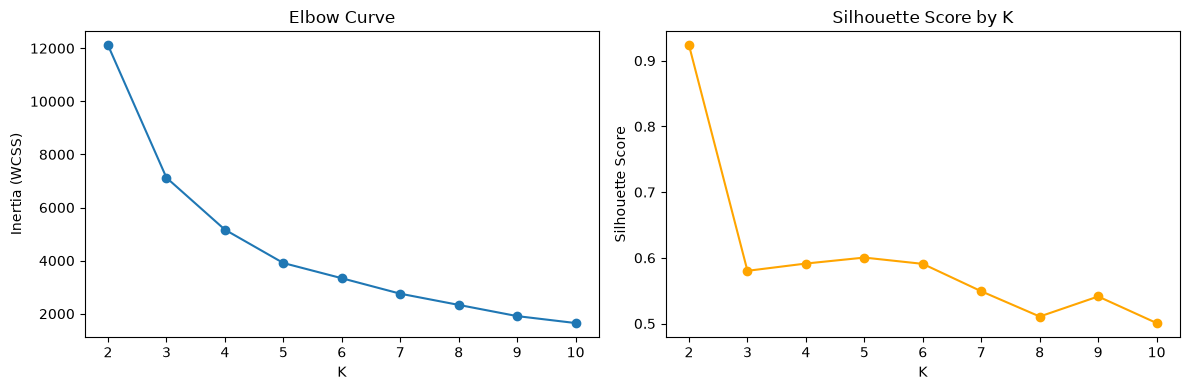

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results["k"], results["inertia"], marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Curve")

axes[1].plot(results["k"], results["silhouette"], marker="o", color="orange")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K")

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=100)
plt.show()

In [6]:
from collections import Counter

for k in [2, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    print(f"K={k} kume buyuklukleri:", sorted(Counter(labels).values()))

K=2 kume buyuklukleri: [18, 5860]
K=5 kume buyuklukleri: [4, 24, 383, 1914, 3553]


### Sonuç ve Optimal K Kararı

**Gözlem 1 — Elbow curve net bir "dirsek" göstermiyor.** Inertia K arttıkça düzgün bir şekilde azalıyor (12114 → 1648), klasik literatürdeki gibi belirgin bir kırılma noktası yok. Bu, perakende RFM verisinde sık görülür çünkü dağılım çok çarpık (`monetary`'nin std'si ortalamasının ~5 katı).

**Gözlem 2 — Silhouette skoru K=2'de en yüksek (0.924) ama bu yanıltıcı.** Küme büyüklüklerine bakınca: K=2 → kümeler **[18, 5860]**. Model sadece 18 aşırı-harcamacı/aşırı-sık-alışveriş yapan müşteriyi (z-score'da `frequency` 30, `monetary` 41 gibi uç değerler — `describe()` çıktısında gördük) ayırıyor, geri kalan 5860 müşteri tek bir kümede toplanıyor. Yüksek silhouette, iyi bir iş segmentasyonu değil, sadece **aşırı uç değerlerin geometrik olarak çok ayrışık olmasından** kaynaklanıyor.

**Gözlem 3 — K=3 ve sonrasında silhouette 0.50-0.60 arasında, en yüksek K=5'te (0.600).** K=5'teki küme büyüklükleri **[4, 24, 383, 1914, 3553]** — burada da en küçük 2 küme (4 ve 24 müşteri) hâlâ uç değerleri yakalıyor, ama kalan 3 küme (383, 1914, 3553) iş açısından kullanılabilir, anlamlı büyüklükte segmentler oluşturuyor.

**Karar: K=5.** Gerekçe:
1. Anlamlı büyüklükteki K değerleri arasında (K≥3) en yüksek silhouette skoru.
2. Gün 2'de NTILE(5) ile kurduğumuz RFM segmentasyonuyla (Champion/At Risk/Hibernating vb. 5 segment) kavramsal olarak örtüşüyor — iş tarafına anlatımı kolaylaşıyor.
3. **Not:** Uç değerlerin (4-24 müşterilik mikro-kümeler) ayrı bir küme olarak çıkması, bu müşterilerin gerçekten "VIP/anormal" olduğunu gösteriyor — ileride bunları kümelemeden önce ayrı ele almak (örnek: IQR ile filtreleme) modelin kalan kümelerini daha da netleştirebilir. Şimdilik kapsam dışı bırakıyorum, ama not olarak bırakıyorum.

## Adım 3: scikit-learn Pipeline — StandardScaler → KMeans

Şu ana kadar `scaler.fit_transform(rfm)` ve `KMeans(...).fit_predict(rfm_scaled)`'i **ayrı ayrı** çağırdık. Bu, keşif (EDA) aşamasında sorun değil, ama production'a taşırken bir riski var:

**Unsupervised öğrenmede "data leakage" şu anlama gelir:** Yeni bir müşteri grubu geldiğinde (örn. `/rfm/recalculate` sonrası yeni RFM verisi), onu kümeye atamak için **eğitimde kullanılan scaler'ın öğrendiği mean/std** ile ölçeklemen gerekir — yeni veriye göre **scaler'ı yeniden fit etmek** ciddi bir hata olur. Çünkü o zaman yeni verinin ölçeği eski küme merkezleriyle (centroid) uyumsuz hale gelir, kümeleme sonuçları anlamsızlaşır.

`Pipeline`, `scaler` ve `kmeans` adımlarını **tek bir nesnede** birleştirir:
- `pipeline.fit(rfm)` → scaler'ı eğitim verisiyle fit eder, KMeans'i scale edilmiş veriyle eğitir — tek çağrı, hata payı yok.
- `pipeline.predict(yeni_veri)` → otomatik olarak **kayıtlı (fit edilmiş) scaler parametreleriyle** dönüştürür, asla yeniden fit etmez.

Bu, "ayrı ayrı `fit_transform` çağırıp birini unutma riski"ni ortadan kaldırır — tam olarak production-ready yapı budur.

In [7]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=5, random_state=42, n_init=10)),
])

# Pipeline ham (olceklenmemis) veriyle fit edilir; olcekleme pipeline'in icinde otomatik olur
pipeline.fit(rfm)
cluster_labels = pipeline.predict(rfm)

rfm_clustered = rfm.copy()
rfm_clustered["cluster"] = cluster_labels
rfm_clustered["cluster"].value_counts().sort_index()

cluster
0     383
1    1914
2      24
3       4
4    3553
Name: count, dtype: int64

### Doğrulama

Adım 2'de K=5 için ayrı `fit_transform` + `fit_predict` ile bulduğumuz küme büyüklükleri **[4, 24, 383, 1914, 3553]** idi. Aynı `random_state` ve `n_init` ile Pipeline üzerinden de aynı sonucu almalıyız — aşağıda kontrol ediyoruz.

In [8]:
assert sorted(rfm_clustered["cluster"].value_counts().tolist()) == [4, 24, 383, 1914, 3553]
print("Pipeline sonuclari Adim 2 ile tutarli.")

Pipeline sonuclari Adim 2 ile tutarli.


### Pipeline'ı diske kaydetme

Üretimde bu pipeline'ı her seferinde sıfırdan eğitmek yerine, eğitilmiş halini diske kaydedip API'den yükleyip kullanmak isteriz (`joblib`, scikit-learn'ün önerdiği serileştirme aracı — `pickle`'dan daha verimli, büyük numpy array'leri için optimize).

In [9]:
import joblib
from pathlib import Path

Path("../models").mkdir(exist_ok=True)
joblib.dump(pipeline, "../models/kmeans_pipeline.joblib")
print("Kaydedildi: models/kmeans_pipeline.joblib")

Kaydedildi: models/kmeans_pipeline.joblib


## Adım 4: Küme Profilleri ve İş Yorumu

Her kümenin ortalama Recency/Frequency/Monetary değerlerine ve müşteri sayısına bakarak, kümelerin gerçekte neyi temsil ettiğini yorumluyoruz.

In [10]:
profile = rfm_clustered.groupby("cluster").agg(
    customer_count=("recency", "size"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    min_monetary=("monetary", "min"),
    max_monetary=("monetary", "max"),
).round(1).sort_values("avg_monetary", ascending=False)

profile

,customer_count,avg_recency,avg_frequency,avg_monetary,min_monetary,max_monetary
cluster,,,,,,
3,4,2.8,212.5,436835.8,295972.6,608821.6
2,24,21.8,119.8,100927.0,15972.8,246973.1
0,383,27.6,28.5,13935.2,1820.4,88704.3
4,3553,75.4,5.1,1911.2,6.2,44534.3
1,1914,471.1,2.2,755.7,3.0,34095.3


### İş Yorumu — Her Kümenin Profili

| Küme | Müşteri Sayısı | Ort. Recency (gün) | Ort. Frequency (fatura) | Ort. Monetary | Yorum |
|---|---|---|---|---|---|
| **3** | 4 | 2.8 | 212.5 | 436.835 £ | **Mega-VIP / toptan alıcı.** Az sayıda ama inanılmaz değerli — son 3 günde alışveriş yapmış, ortalama 212 fatura, yüz binlerce £ harcama (min 295.972 £). Muhtemelen bireysel tüketici değil, toptan/kurumsal alıcı. |
| **2** | 24 | 21.8 | 119.8 | 100.927 £ | **VIP / üst segment sadık müşteri.** Cluster 3'ten daha geniş ama hâlâ çok değerli, yakın zamanda ve sık alışveriş yapıyor. |
| **0** | 383 | 27.6 | 28.5 | 13.935 £ | **Sadık / düzenli müşteri (çekirdek segment).** Yakın zamanda alışveriş yapmış, makul sıklıkta, sağlam bir harcama seviyesi — klasik "Champion/Loyal" kitlesi. |
| **4** | 3553 | 75.4 | 5.1 | 1.911 £ | **Ortalama / sıradan müşteri (en büyük kitle).** Recency orta seviyede, frequency ve monetary düşük — büyük çoğunluk bu profilde, "kitle pazarı" diyebiliriz. |
| **1** | 1914 | 471.1 | 2.2 | 756 £ | **Pasif / kaybedilmiş müşteri.** Ortalama ~471 gün (15+ ay) önce alışveriş yapmış, çok düşük frequency/monetary — Gün 2'deki "Hibernating" segmentiyle örtüşüyor. |

**Genel okuma:** Kümeler, monetary'ye göre sıralandığında doğal bir **değer/aktivite gradyanı** oluşturuyor: 3 → 2 → 0 → 4 → 1. Bu, K-Means'in veri içindeki gerçek bir yapıyı yakaladığını gösteriyor (rastgele bölünme değil). Cluster 3 ve 2 (toplam 28 müşteri, %0.5'ten az) cirosun büyük bir kısmını oluşturuyor olabilir — bu, klasik "az sayıda müşteri, orantısız değer" (Pareto) durumu, iş tarafına özellikle vurgulanmalı: bu 28 müşteri özel hesap yöneticisi/öncelikli destek alması gereken hesaplar.

## Adım 5: DBSCAN ile Karşılaştırma

K-Means, küme sayısını (K) önceden istiyor ve her noktayı zorla bir kümeye atıyor. **DBSCAN** ise yoğunluk tabanlı çalışır: birbirine yakın noktaları kümeler, yeterince yoğun bir bölgeye düşmeyen noktaları **"noise" (gürültü, etiket = -1)** olarak işaretler — küme sayısını önceden belirtmene gerek yok.

İki parametresi var: `eps` (komşuluk yarıçapı) ve `min_samples` (bir bölgenin "yoğun" sayılması için gereken min nokta sayısı). `eps`'i rastgele seçmemek için **k-distance grafiği** kullanıyoruz: her noktanın k. en yakın komşusuna olan uzaklığını sıralayıp çiziyoruz, eğri keskin yükseldiği yer ("dirsek") makul bir `eps` değeri verir.

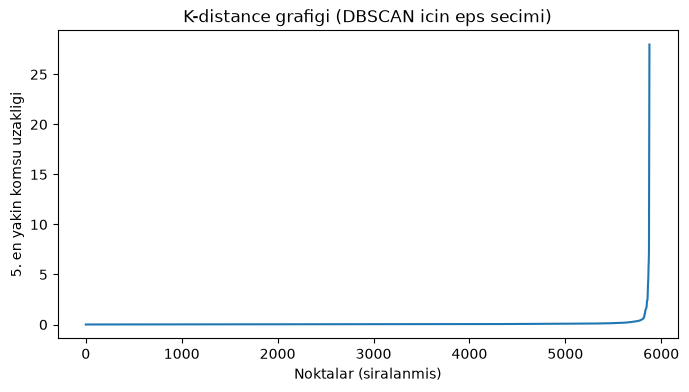

In [11]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(rfm_scaled)
distances, _ = neighbors.kneighbors(rfm_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Noktalar (siralanmis)")
plt.ylabel(f"{min_samples}. en yakin komsu uzakligi")
plt.title("K-distance grafigi (DBSCAN icin eps secimi)")
plt.savefig("dbscan_kdistance.png", dpi=100)
plt.show()

K-distance grafiğinde mesafelerin %95-97'lik dilimden sonra hızla arttığını görüyoruz (~0.17'den ~0.26'ya, sonra %99'da 0.72'ye fırlıyor) — bu, verinin büyük kısmının çok yoğun/sıkışık olduğunu, küçük bir kısmının ise çok seyrek olduğunu gösteriyor (beklenen bir şey: RFM'de az sayıda aşırı-uç müşteri var). Bu aralıktan birkaç `eps` adayı deniyoruz.

In [12]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

for eps in [0.15, 0.2, 0.3, 0.5, 0.8]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(rfm_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    if n_clusters >= 2 and n_noise < len(labels):
        mask = labels != -1
        sil = silhouette_score(rfm_scaled[mask], labels[mask])
    else:
        sil = None
    print(f"eps={eps:<5} kume_sayisi={n_clusters:<3} noise={n_noise:<5} silhouette(noise haric)={sil}")

eps=0.15  kume_sayisi=2   noise=285   silhouette(noise haric)=0.19936195933787546


eps=0.2   kume_sayisi=2   noise=187   silhouette(noise haric)=0.5300683727061808


eps=0.3   kume_sayisi=2   noise=123   silhouette(noise haric)=0.6738553333098686


eps=0.5   kume_sayisi=1   noise=65    silhouette(noise haric)=None


eps=0.8   kume_sayisi=1   noise=52    silhouette(noise haric)=None


Denenen tüm `eps` değerlerinde DBSCAN **en fazla 2 küme** buluyor; `eps=0.5` ve üstünde tüm yoğun bölge tek kümeye birleşiyor. En iyi silhouette'i veren `eps=0.3`'ün profiline bakalım.

In [13]:
db = DBSCAN(eps=0.3, min_samples=5)
db_labels = db.fit_predict(rfm_scaled)

rfm_dbscan = rfm.copy()
rfm_dbscan["cluster"] = db_labels

db_profile = rfm_dbscan.groupby("cluster").agg(
    customer_count=("recency", "size"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
).round(1)

db_profile

,customer_count,avg_recency,avg_frequency,avg_monetary
cluster,,,,
-1,123,124.8,55.4,53733.0
0,5750,202.7,5.2,1917.1
1,5,5.4,53.8,22246.3


### Sonuç: Neden K-Means'i Seçtim (DBSCAN'a Karşı)

**Gözlem.** Denenen her `eps` değerinde (0.15 - 0.8) DBSCAN en fazla **2 küme** buluyor, `eps≥0.5`'te ise hepsi tek kümeye birleşiyor. En iyi sonuçta (`eps=0.3`) bile profil şöyle:

- **Cluster -1 (noise): 123 müşteri** — recency/frequency/monetary'si tutarsız, "kategorize edilemeyen" bir çöp kutusu.
- **Cluster 0: 5750 müşteri (toplamın %98'i)** — tek bir kümede toplanmış, içinde hem ortalama hem biraz daha aktif müşteriler var, ayrışma yok.
- **Cluster 1: 5 müşteri** — küçük bir yüksek-değer grubu.

K-Means'in bulduğu **5 anlamlı, kademeli segment** (mega-VIP → VIP → sadık → ortalama → pasif) burada tamamen kayboluyor.

**Neden DBSCAN burada başarısız oluyor:** DBSCAN tek bir global `eps` ile çalışır, ama RFM verimiz **farklı yoğunluklarda** bölgelerden oluşuyor — müşterilerin büyük kısmı (recency/frequency/monetary'de) çok sıkışık bir bölgede, küçük bir kısmı (VIP'ler) çok seyrek bir bölgede. Tek `eps` ile hem sıkışık bölgeyi anlamlı parçalara ayırıp hem de seyrek bölgeyi yakalayamazsın — biri feda edilir. Bu, DBSCAN'ın literatürde bilinen **"değişken yoğunluk" zayıflığı**.

**DBSCAN ne zaman daha iyi olurdu:**
- Kümelerin **şekli** küresel değilse (K-Means küresel/dışbükey kümeler varsayar; DBSCAN keyfi şekilleri yakalayabilir) — örnek: coğrafi konum kümeleme, yoğunluk haritaları.
- **Asıl hedef anomali/fraud tespiti** ise — "noise" etiketi burada bir kusur değil, tam da istenen sonuç (örnek: kredi kartı dolandırıcılığı tespiti, ağ trafiği anomalisi).
- Küme sayısının **gerçekten bilinmediği**, veri yoğunluğunun nispeten homojen olduğu durumlar.

**Neden K-Means'i seçtim:**
1. **İş ihtiyacı "her müşteri bir segmentte olsun"** — pazarlama ekibi "bu 123 müşteriyi göz ardı et" diyemez, her müşteriye bir aksiyon (kampanya, öncelik) atanabilmeli. K-Means bunu yapısal olarak garanti eder, DBSCAN'ın "noise" kavramı bu ihtiyaçla çatışıyor.
2. **K-Means, veride gerçekten var olan kademeli yapıyı yakaladı** — bunu Adım 2'de silhouette skoruyla, Adım 4'te de iş mantığıyla doğruladık (tesadüfi değil).
3. **Production'a taşıması daha kolay** — `Pipeline` + `joblib` ile tek nesne, yeni müşteri geldiğinde `predict()` çağırman yeterli. DBSCAN'da "yeni bir nokta hangi kümeye girer" sorusu doğası gereği daha belirsizdir (DBSCAN'ın klasik hâli `.predict()` desteklemez, yeni noktayı mevcut kümelere atamak için ek mantık yazman gerekir).

**Sonuç:** Bu projede K-Means doğru seçim; DBSCAN'ı "daha mı iyi" diye değil, "bu problem için doğru araç mı" diye değerlendirip elemek, modelin kendisinden daha değerli bir adım.